In [7]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt

## 3

In [10]:
def hilbert(n):
    m = np.zeros((n,n))
    for i in range(n):
        for j in range(n):
            m[i][j] = 1/((i+1)+(j+1)-1)
    return m

In [12]:
n = []
res_norms = []
err_norms = []
rel_errs = []
cond_Hs = []

for i in range(2,15):
    n.append(i)
    H = hilbert(i)
    ones= np.ones(i)
    b = H @ ones
    x_hat = np.linalg.solve(H, b)

    r = (b - H * x_hat)
    delta_x = (ones - x_hat)
    res_norm = np.linalg.norm(r,ord = np.inf)
    res_norms.append(res_norm)
    err_norm = np.linalg.norm(delta_x, ord = np.inf)
    err_norms.append(err_norm)
    rel_err = err_norm / np.linalg.norm(ones,ord = np.inf)
    rel_errs.append(rel_err)
    cond_H = np.linalg.cond(H, np.inf)
    cond_Hs .append(cond_H)


d = {"size": n, "res_norms": res_norms, "err_norms":err_norms, "rel_errs": rel_errs, "cond_Hs": cond_Hs}
df = pd.DataFrame(d)
df
    

,size,res_norms,err_norms,rel_errs,cond_Hs
0,2,1.500000,6.661338e-16,6.661338e-16,2.700000e+01
1,3,2.916667,9.992007e-15,9.992007e-15,7.480000e+02
2,4,4.316667,1.949552e-13,1.949552e-13,2.837500e+04
3,5,5.710714,3.096567e-11,3.096567e-11,9.436560e+05
4,6,7.101984,4.153276e-10,4.153276e-10,2.907028e+07
5,7,8.491739,1.902250e-08,1.902250e-08,9.851949e+08
6,8,9.880578,2.351178e-07,2.351178e-07,3.387279e+10
7,9,11.268821,1.597544e-05,1.597544e-05,1.099650e+12
8,10,12.656657,8.145608e-04,8.145608e-04,3.535295e+13
9,11,14.044199,1.406079e-02,1.406079e-02,1.230504e+15


## Write-up:
Based on the data, the Hilbert matrix becomes ill conditioned sometime between n = 11 and n = 12. As n varies, the number of correct digits roughly is -log_10(K(A) e_mach).


## 4

In [18]:
def lu_fac(A, b):
    start_fac = time.time()
    n = A.shape[0]
    L = np.eye(n)
    U = A.copy()
    for r in range(n-1):
        for c in range(r+1, n):
            if U[r, r] == 0:
                raise ValueError("Zero pivot encountered!")
            L[c, r] = U[c, r] / U[r, r]
            U[c, r:] = U[c, r:] - L[c, r] * U[r, r:]
    end_fac = time.time()
    lu_fac_time = end_fac - start_fac
    
    start_l = time.time()
    n_l = L.shape[0]
    y = np.zeros(n_l)
    for i in range(n_l):
        y[i] = b[i] - np.dot(L[i, :i], y[:i])
    end_l = time.time()
    l_time = end_l-start_l
    
    start_u = time.time()
    n_u = U.shape[0]
    x = np.zeros(n_u)
    for i in reversed(range(n_u)):
        if U[i,i] == 0:
            raise ValueError("Zero diagonal element in U!")
        x[i] = (y[i] - np.dot(U[i, i+1:], x[i+1:])) / U[i,i]
    end_u = time.time()
    u_time = end_u-start_u
    
    return L, U, x, l_time, u_time, lu_fac_time

In [19]:
np.random.seed(42)
A = np.random.rand(3, 3)
x_true = np.ones(3)
b = A @ x_true

L, U, x, t_fwd, t_bwd, t_lu = lu_fac(A, b)

print("Computed x:", x)
print("Error (∞-norm):", np.linalg.norm(x_true - x, np.inf))
print("LU factorization time:", t_lu)
print("Forward substitution time:", t_fwd)
print("Backward substitution time:", t_bwd)

Computed x: [1. 1. 1.]
Error (∞-norm): 4.6629367034256575e-15
LU factorization time: 0.0006186962127685547
Forward substitution time: 0.0008373260498046875
Backward substitution time: 4.792213439941406e-05


In [20]:
np.random.seed(42)
sizes = np.unique(np.round(np.logspace(2, np.log10(5000), 10)).astype(int))
lu_times = []
solve_times = []

for n in sizes:
    print(f"Running for n = {n} ...")
    A = np.random.rand(n, n)
    b = np.random.rand(n)

    L, U, x, t_fwd, t_bwd, t_lu = lu_fac(A, b)

    lu_times.append(t_lu)
    solve_times.append(t_fwd + t_bwd)

Running for n = 100 ...
Running for n = 154 ...
Running for n = 239 ...
Running for n = 368 ...
Running for n = 569 ...
Running for n = 879 ...
Running for n = 1357 ...
Running for n = 2096 ...
Running for n = 3237 ...
Running for n = 5000 ...


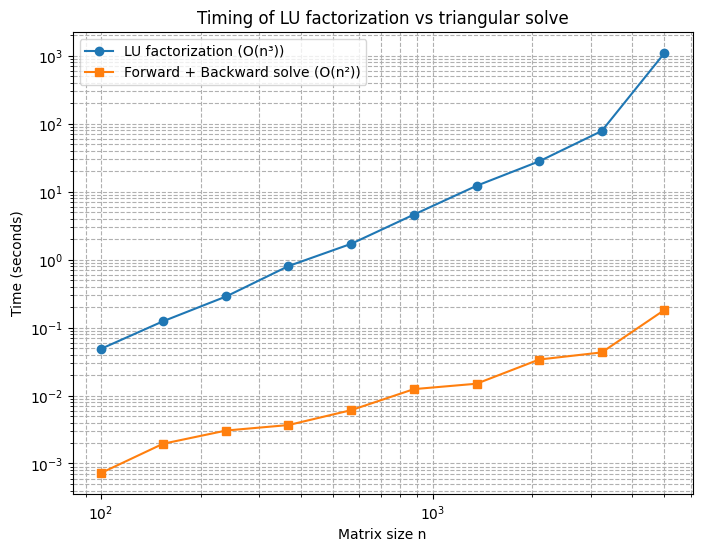

In [21]:
plt.figure(figsize=(8,6))
plt.loglog(sizes, lu_times, 'o-', label='LU factorization (O(n³))')
plt.loglog(sizes, solve_times, 's-', label='Forward + Backward solve (O(n²))')
plt.xlabel('Matrix size n')
plt.ylabel('Time (seconds)')
plt.title('Timing of LU factorization vs triangular solve')
plt.legend()
plt.grid(True, which='both', ls='--')
plt.show()

## Write-up:
At first i tried to use the max value of 25,000 however my computer is unable to run it primarily because it times out beyond 6 hours. I instead took 5000 as the maximum. The above graph has 2 curves, one that shows the LU factorization time and the other shows the time to complete forwards and backwards substitution. For LU factorization, the curve is relatively smooth and it appears as a straight line due to the distortion created by the values on the x and y axes. For the second line, it appears less stable and there was more variance based on matrix size, this could be attributed to the fact the numbers are random and the the distortion created by the values on the x and y axes.